## Laboratorio 1 de sistemas de control

### 1: Modelación del sistema

Se modeló el sistema dinámico con una ecuación del movimiento no lineal:

$$ \ddot\theta (t) = \frac{mlg}{2I_A} sin(\theta (t)) + \frac{C}{I_A} \dot\theta (t) $$

donde: 

$$ I_A = \frac{1}{4} m_{barra} R^2 + \frac{1}{3}m_{barra}  L^2$$

Creo que ahora está buena (?)

In [2]:
import numpy as np
from scipy.integrate import solve_ivp, odeint
import matplotlib.pyplot as plt

In [3]:
m_barra = 165e-3 # kg
m_soporte = (169.9 - 165)*10**-3 # kg

L = (25 * 25.4 + 17.7)*10**-3 # m
d = 6.5e-3 # m
C = 0.00106 # kgm^2
c_isma=0
g = 9.807 # m/s^2

I_A = 0.25*m_barra*(d/2)**2 + (1/3)*m_barra*L**2

In [4]:
print(2*(0.5*m_barra*L*g * I_A)**.5)
print(I_A)
print(L)

0.22247481752802958
0.023431386653125
0.6527000000000001


In [5]:
def dThetadt(t, Y):
    y1, y2 = Y
    return [y2, -m_barra*L*g*np.sin(y1)/(2*I_A) - C/I_A*y2]

In [6]:
t = np.linspace(0,100,1000)

sol90 = odeint(dThetadt, y0=(-np.pi/2, 0), t=t, tfirst=True)

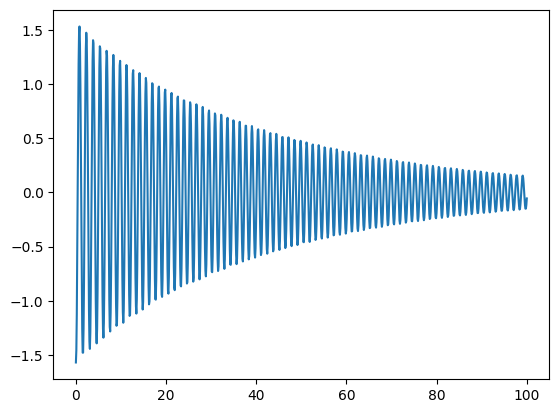

In [7]:
plt.plot(t, sol90.T[0])

Ecuación de barra delgada simple.
$$\ddot \theta (t) = -\dot \theta (t) \cdot C \frac{3}{L} - sin(\theta(t)) \cdot \frac{g3}{2L}$$

In [8]:
def dThetadt_isma(t, Y):
    theta, dtheta = Y
    return [dtheta, -np.sin(theta)*(3*g)/(2*L) - c_isma*3/L*dtheta]

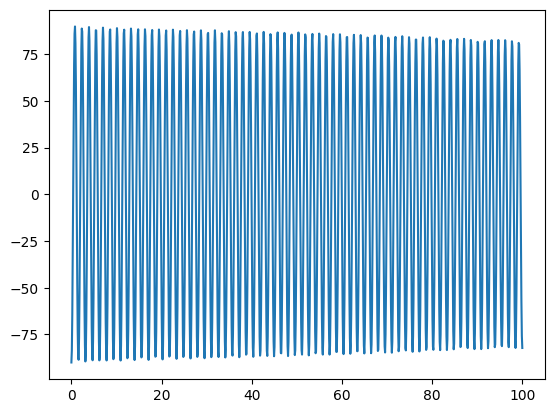

In [9]:
tiempo_inicio=0
tiempo_fin=100
t_otro=np.linspace(tiempo_inicio, tiempo_fin, 1000)
sol_isma90=solve_ivp(dThetadt_isma, t_span=[tiempo_inicio, tiempo_fin], y0=(-np.pi/2, 0), t_eval=t_otro)
# print(sol_isma90)
plt.plot(t_otro, np.rad2deg(sol_isma90.y[0]))

### 2: Actividad experimental

#### Almacenamiento de datos

In [10]:
with open('g7_21.txt', 'r') as archivo:
    lineas21 = [line.rstrip() for line in archivo]
with open('g7_60.txt', 'r') as archivo:
    lineas60 = [line.rstrip() for line in archivo]
with open('g7_90.txt', 'r') as archivo:
    lineas90 = [line.rstrip() for line in archivo]


tiempo21, tiempo60, tiempo90 = [], [], []
theta21, theta60, theta90 = [], [], []

for i in lineas21[1:]:
    tiempo21.append(float(i.split(',')[0]))
    theta21.append(float(i.split(',')[1]))

for i in lineas60[1:]:
    tiempo60.append(float(i.split(',')[0]))
    theta60.append(float(i.split(',')[1]))

for i in lineas90[1:]:
    tiempo90.append(float(i.split(',')[0]))
    theta90.append(float(i.split(',')[1]))

#### Gráficos

Se configura la librería:

In [11]:
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [8,6]

##### 21 Grados

In [12]:
máximos21 = []
segmento = []
# for i in range(len(tiempo21[880:])-2):
    # if True: print('yea')

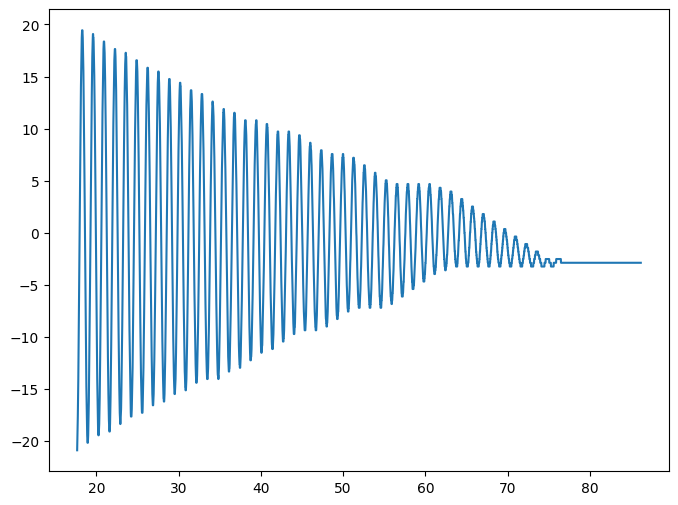

In [13]:
plt.plot(tiempo21[883:], theta21[883:])

##### 60 Grados

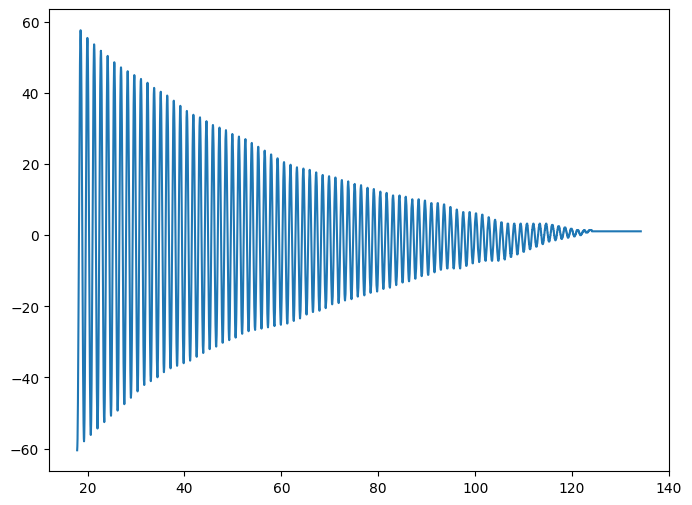

In [14]:
plt.plot(tiempo60[892:], theta60[892:])

##### 90 Grados

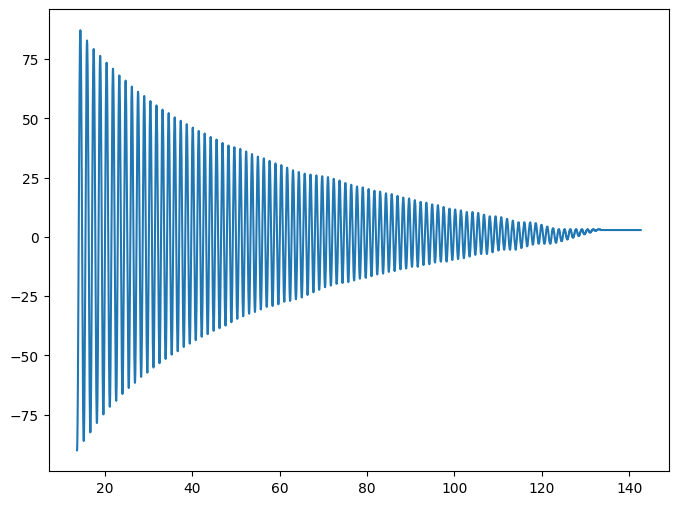

In [15]:
plt.plot(tiempo90[502:], theta90[502:])

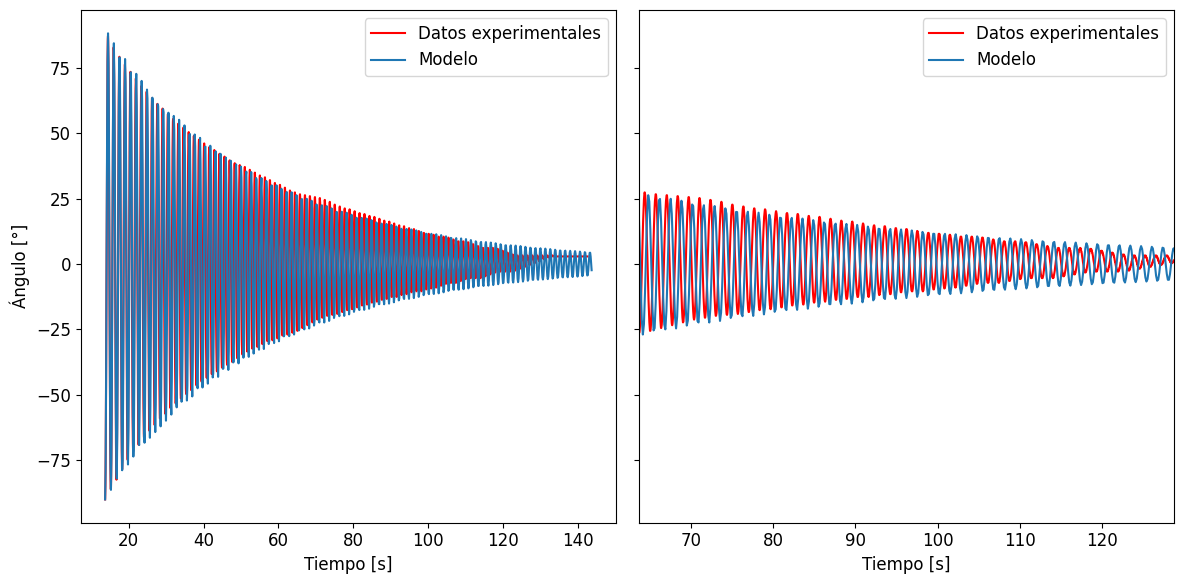

In [16]:
plt.rcParams['font.size'] = 12

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
L = (25 * 25.4 + 17.7)*10**-3 # m
d = 6.5e-3 # m
C = 0.00106 # kgm^2
c_isma=0
g = 9.807 # m/s^2

I_A = 0.25*m_barra*(d/2)**2 + (1/3)*m_barra*L**2
C=0.00106
c_isma=0.00945
t_inicio=0
t_fin=130
t=np.linspace(t_inicio, t_fin, 1000)
sol90_martin = odeint(dThetadt, y0=(-np.pi/2, 0), t=t, tfirst=True)
# sol90_isma=solve_ivp(dThetadt_isma,t_span=[t_inicio, t_fin], y0=(-np.pi/2, 0), t_eval=t)
print()
# plt.plot([i+tiempo90[502]for i in t], np.rad2deg(sol90_isma.y[0]), color='orange')

ax1.plot(tiempo90[502:], theta90[502:], color='red', label='Datos experimentales')
ax1.plot([i+tiempo90[502]for i in t], np.rad2deg(sol90_martin.T[0]), label='Modelo')
ax1.set_xlabel('Tiempo [s]')
ax1.set_ylabel('Ángulo [°]')
ax1.legend()

ax2.plot(tiempo90[502:], theta90[502:], color='red', label='Datos experimentales')
ax2.plot([i+tiempo90[502]for i in t], np.rad2deg(sol90_martin.T[0]), label='Modelo')
ax2.set_xlabel('Tiempo [s]')
ax2.legend()

ax2.set_xlim(50+tiempo90[502], 50+ tiempo90[502]+65)

plt.subplots_adjust(wspace=0)
plt.tight_layout()

Sea, al asumir una barra delgada un proporcional de amortiguación:
$$C=0.0095$$
obtenido al ojo.  
Y para el cilindro:
$$C=0.00106$$
obtenida al ojo también.

0.6434000000000001

13.7


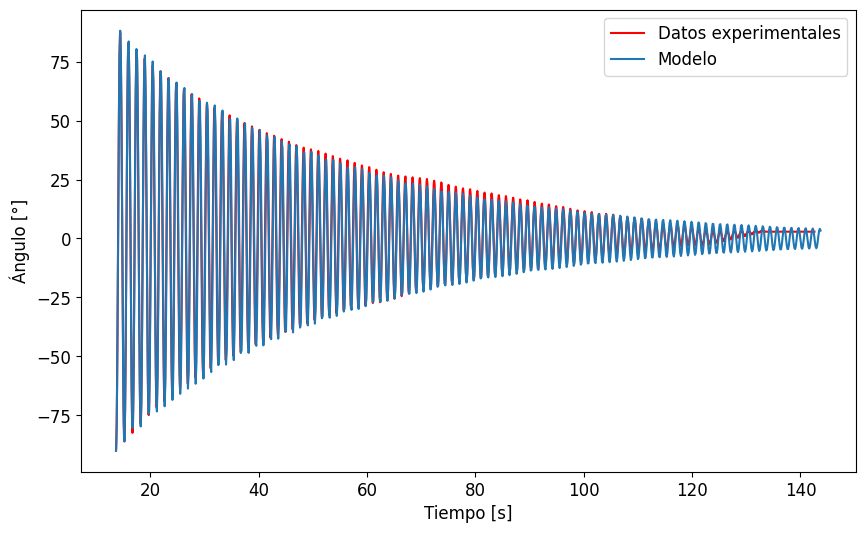

In [50]:
plt.rcParams['figure.figsize'] = [10,6]
L = (25 * 25.4 + 17.7)*10**-3 -0.0093 # m
d = 6.5e-3 # m
C = 0.00106 # kgm^2
c_isma=0
g = 9.807 # m/s^2
print(L)
I_A = 0.25*m_barra*(d/2)**2 + (1/3)*m_barra*L**2
C=0.00106
c_isma=0.00945
t_inicio=0
t_fin=130
t=np.linspace(t_inicio, t_fin, 1000)
sol90_martin = odeint(dThetadt, y0=(-np.pi/2, 0), t=t, tfirst=True)
# sol90_isma=solve_ivp(dThetadt_isma,t_span=[t_inicio, t_fin], y0=(-np.pi/2, 0), t_eval=t)
print()
# plt.plot([i+tiempo90[502]for i in t], np.rad2deg(sol90_isma.y[0]), color='orange')
print(tiempo90[502])

plt.plot(tiempo90[502:], theta90[502:], color='red', label='Datos experimentales')
plt.plot([i+tiempo90[502]for i in t], np.rad2deg(sol90_martin.T[0]), label='Modelo')
plt.xlabel('Tiempo [s]')
plt.ylabel('Ángulo [°]')
plt.legend()

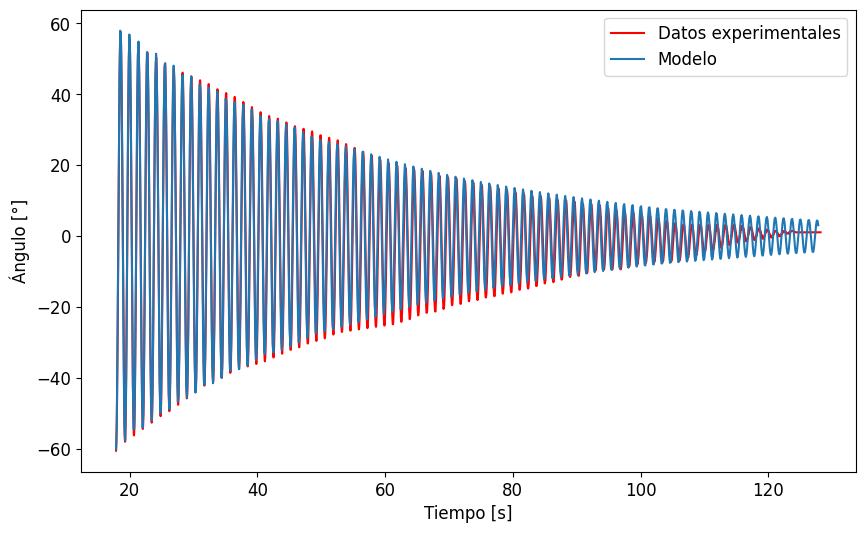

In [18]:
t_inicio=0
t_fin=110
t=np.linspace(t_inicio, t_fin, 1000)
sol60_martin = odeint(dThetadt, y0=(-np.deg2rad(60), 0), t=t, tfirst=True)
# sol60_isma=solve_ivp(dThetadt_isma,t_span=[t_inicio, t_fin], y0=(-np.deg2rad(60), 0), t_eval=t)
print()
# plt.plot([i+tiempo60[892]for i in t], np.rad2deg(sol60_isma.y[0]), color='orange')
plt.plot(tiempo60[892:-300], theta60[892:-300], color='red', label='Datos experimentales')
plt.plot([i+tiempo60[892]for i in t], np.rad2deg(sol60_martin.T[0]), label='Modelo')
plt.xlabel('Tiempo [s]')
plt.ylabel('Ángulo [°]')
plt.legend()

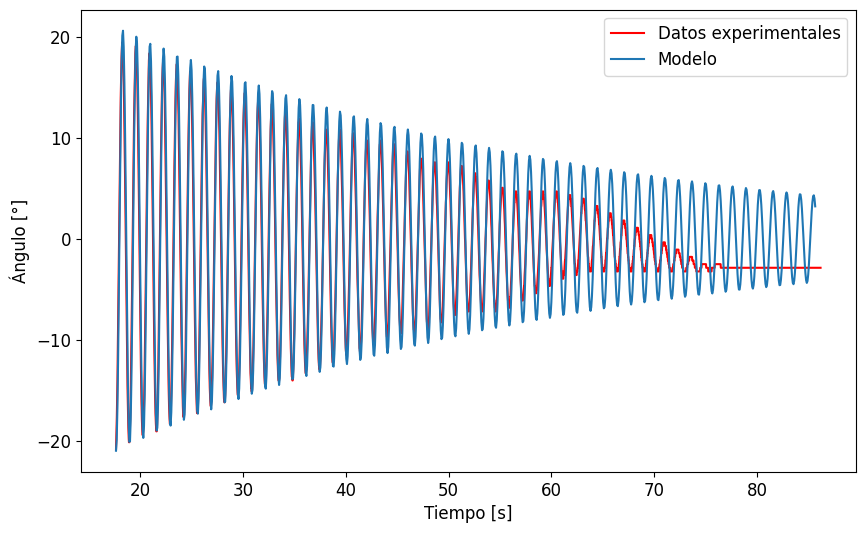

In [19]:
t_inicio=0
t_fin=68
t=np.linspace(t_inicio, t_fin, 1000)
sol21_martin = odeint(dThetadt, y0=(-np.deg2rad(21), 0), t=t, tfirst=True)
# sol21_isma=solve_ivp(dThetadt_isma,t_span=[t_inicio, t_fin], y0=(-np.deg2rad(21), 0), t_eval=t)
print()
# plt.plot([i+tiempo21[883]for i in t], np.rad2deg(sol21_isma.y[0]), color='orange')
plt.plot(tiempo21[883:], theta21[883:], color='red', label='Datos experimentales')
plt.plot([i+tiempo21[883]for i in t], np.rad2deg(sol21_martin.T[0]), label='Modelo')
plt.xlabel('Tiempo [s]')
plt.ylabel('Ángulo [°]')
plt.legend()


### Comparación!

Se compara por el error medio cuadrado de ambos sets de datos:

In [ ]:
def error_medio_cuadrado(exper, anal):
    error = 0
    for i in range(len(exper)):
        error += 1/len(exper) * (exper[i]-anal[i])**2
        # print(exper[i])
        # print(anal[i])
        # print('--')
    return error

In [58]:
t_inicio=0
# t_fin=130
# t=np.linspace(t_inicio, t_fin, 1000)
pasos=len(theta90[502:])
t_fin=tiempo90[-1]-tiempo90[502]
print(t_fin)

t=np.linspace(t_inicio, t_fin, pasos)
sol90_martin = odeint(dThetadt, y0=(-np.pi/2, 0), t=t, tfirst=True)
error_90 = error_medio_cuadrado(np.rad2deg(sol90_martin.T[0]), theta90[502:])

t_inicio=0
# t_fin=110
# t=np.linspace(t_inicio, t_fin, 1000)
pasos=len(theta60[892:-300])
t_fin=tiempo60[-300]-tiempo60[892]
print(t_fin)
t=np.linspace(t_inicio, t_fin, pasos)
sol60_martin = odeint(dThetadt, y0=((-np.deg2rad(60)),0), t=t, tfirst=True)
error_60 = error_medio_cuadrado(np.rad2deg(sol60_martin.T[0]), theta60[892:-300])

t_inicio=0
# t_fin=68
# t=np.linspace(t_inicio, t_fin, 1000)
pasos=len(theta21[883:])
t_fin=tiempo21[-1]-tiempo21[883]
print(t_fin)
t=np.linspace(t_inicio, t_fin, pasos)
sol21_martin = odeint(dThetadt, y0=(-np.deg2rad(21), 0), t=t, tfirst=True)
error_21 = error_medio_cuadrado(np.rad2deg(sol21_martin.T[0]), theta21[883:])
# print(np.rad2deg(sol90_martin.T[0]))
print(error_21)
print(error_60)
print(error_90)

128.88000000000002
-90.0
-90.0
--
-89.73809016275152
-89.64
--
-88.95269012295321
-88.56
--
-87.64438722908027
-87.12
--
-85.81405085719383
-84.96
--
-83.46315880452943
-82.44
--
-80.59425186921011
-79.2
--
-77.21150576903581
-75.6
--
-73.32141438371539
-71.64
--
-68.93356223671671
-66.96
--
-64.06145524656951
-61.92
--
-58.723367932106626
-56.16
--
-52.94314874789889
-50.4
--
-46.75091445221253
-43.92
--
-40.18355131143578
-37.08
--
-33.28494642702388
-30.24
--
-26.10587436698315
-23.04
--
-18.703488825657384
-15.48
--
-11.140403180692447
-7.92
--
-3.4833861221281963
-0.36
--
4.1982552599210115
7.2
--
11.83449166136709
14.76
--
19.35644585249194
22.32
--
26.69817602802341
29.52
--
33.79823196080146
36.36
--
40.600878973804505
42.84
--
47.05692742902813
49.32
--
53.12415162833935
55.08
--
58.76732307238918
60.48
--
63.957916403509586
65.52
--
68.67356074580408
69.84
--
72.89731980105165
73.8
--
76.61687766665581
77.4
--
79.82369845825966
80.28
--
82.5122139511634
82.8
--
84.67907972066